# Table of Contents

<span style="font-size:16px;">
    
**1.** Data Description <br>
**2.** Data Loading <br>
**3.** Data Preprocessing <br>
**4.** Exploratory Data Analysis (EDA)<br>
**5.** Feature Engineering <br>
**6.** Model Selection <br>
**7.** Model Evaluation <br>
**8.** Test Set <br>
**9.**  Sanity Check <br>
**10.** Visualization <br>
**11.** Conclusion <br>
**12.** Summary <br>

</span>

## Zyfra - Gold Recovery Prediction - Using Machine Learning

# Task Description

<span style="font-size:16px;">	
    
This project was provided by `Zyfra`, an efficiency solutions developer for heavy industry. In this project, we are to prepare a prototype of a Machine learning model that should predict the amount of **`gold`** recovered from **`Gold Ore`**. The model will help optimize gold production and eliminate unprofitable parameters
</span>

# Data Description

<span style="font-size:16px;">	
    
We are provided data on gold ore extraction and purification in the following csv files:

- **`gold_recovery_train.csv`**
- **`gold_recovery_test.csv`**
- **`gold_recovery_full.csv`**

Source Dataset **(22,716 entries)** contains all of the pertinent parameters and outputs related to the technological process for `Gold Ore` refinement. The source dataset has already been split into a `training` and `test` set **(16,860 and 5,856 entries respectively)**. Some of the features are absent in the `test` set and will be addressed during the project.  
**The project goal is** to find the best model according to the symmetric `Mean Absolute Percentage Error` (**`sMAPE`**) metric using the predicted `rougher` and `final concentrate recovery` values.  
Each entry of the dataset should be uniquely identifiable by **`date`** column.   
Column names follow the format ***[stage].[parameter_type].[parameter_name]***, where the possible values are as follows:

Possible values for ***[stage]***:
- **`rougher`**: flotation
- **`primary_cleaner`**: primary purification
- **`secondary_cleaner`**: secondary purification
- **`final`**: final characteristics

Possible values for ***[parameter_type]***:

- **`input`**: raw material parameters
- **`output`**: product parameters
- **`state`**: parameters characterizing the current state of the stage
- **`calculation`**: calculation characteristics

</span>

# Imports

In [23]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")  # nice background for charts

import plotly.graph_objects as go
import plotly.express as px

from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.metrics import make_scorer

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

import sys
import warnings
warnings.filterwarnings("ignore")
if not sys.warnoptions:
       warnings.simplefilter("ignore")

print("Setup Complete")

Setup Complete


# Data Load

In [2]:
try:
    df_full = pd.read_csv('C:/Users/elesg/OneDrive/Desktop/DS-project/gold_recovery_full.csv')
    df_train = pd.read_csv('C:/Users/elesg/OneDrive/Desktop/DS-project/gold_recovery_train.csv')
    df_test = pd.read_csv('C:/Users/elesg/OneDrive/Desktop/DS-project/gold_recovery_test.csv')
    
except:
    print("File not found. Check the path.")

In [3]:
df_full.sample()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
16301,2017-11-24 04:59:59,4.942678,9.525688,11.505258,48.138383,57.512465,14.834473,4.523484,11.506913,6.168163,234.903543,14.046427,7.199999,2.72614,11.709472,11.607709,16.539947,28.922117,22.390218,7.197423,10.204884,9.668983,1501.644093,-497.298652,1500.65446,-503.528857,1502.996686,-497.03644,1500.410517,-559.140517,49455.25423,3319.791271,3319.73143,2.156493,13.018534,5.736978,487.599437,45.817773,35.637467,12.37175,17.001728,7.598707,16.998512,7.596712,15.416053,8.849666,34.745538,20.446637,92.316154,5.843729,0.666365,11.567618,2.153574,1201.32455,-399.894714,1000.089533,-499.880275,1001.609055,-499.810247,800.402783,-499.948836,799.907618,-500.142377,699.971875,-500.501647,18.356428,8.201099,9.392908,9.816488,22.086991,-499.701059,19.975367,-499.537862,30.004558,-499.923474,22.053093,-499.982089,17.045912,-497.671505,14.930834,-497.893598,10.991923,-506.983445,8.997611,-495.26854,15.99659,-503.380378


In [4]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea

### Notes for Preprocessing
<span style="font-size:16px;">

The following data preprocessing steps were applied to ensure the dataset is clean, consistent, and suitable for machine learning models:

**Convert data types:**  
- The date column will be converted from object to datetime format for proper time-based operations.  
**Compare Train and Test sets:**  
- Check for missing or mismatched columns between the training and test datasets to ensure consistency.  
**Handle target variables:**  
- Target columns will be identified and aligned appropriately. Rows with missing target values will be removed, as they are essential for supervised learning.  
**Handle missing values:**  
- Missing values in target columns will be dropped.  
Remaining missing values in features will be handled using forward fill (ffill), followed by dropping any residual nulls.  
**Validate recovery calculation:**  
- The recovery metric will be recalculated using the provided formula and compared with the dataset values to verify correctness.  
**Remove duplicates:**  
- Duplicate rows will be identified and removed to avoid bias and data leakage.  
**Outlier and consistency check:**  
- Numerical features will be analyzed for outliers and anomalies to improve data quality and model performance.  
</span>

# Data Preprocessing
### Data Type Conversion

In [7]:
df_full['date'] = pd.to_datetime(df_full['date'], format='%Y-%m-%d %H:%M:%S')
df_train['date'] = pd.to_datetime(df_train['date'], format='%Y-%m-%d %H:%M:%S')
df_test['date'] = pd.to_datetime(df_test['date'], format='%Y-%m-%d %H:%M:%S')

### Missing Values Handling

In [8]:
missing_cols = df_train.drop(df_test.columns, axis=1)
missing_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16788 non-null  float64
 1   final.output.concentrate_pb                         16788 non-null  float64
 2   final.output.concentrate_sol                        16490 non-null  float64
 3   final.output.concentrate_au                         16789 non-null  float64
 4   final.output.recovery                               15339 non-null  float64
 5   final.output.tail_ag                                16794 non-null  float64
 6   final.output.tail_pb                                16677 non-null  float64
 7   final.output.tail_sol                               16715 non-null  float64
 8   final.output.tail_au                                16794 non-null  float64


In [9]:
# Adding missing Target columns to Test set

df_test = df_test.merge(df_full[['date', 'rougher.output.recovery', 'final.output.recovery']], on='date', how='inner')

In [10]:
#Checking null values 

df_full.isna().sum().sort_values(ascending=False)

rougher.output.recovery                     3119
rougher.output.tail_ag                      2737
rougher.output.tail_au                      2736
rougher.output.tail_sol                     2736
rougher.input.floatbank11_xanthate          2257
                                            ... 
primary_cleaner.state.floatbank8_b_level      43
primary_cleaner.state.floatbank8_c_level      43
primary_cleaner.state.floatbank8_d_level      43
primary_cleaner.input.feed_size                0
date                                           0
Length: 87, dtype: int64

In [11]:
df_train.isna().sum().sort_values(ascending=False)

rougher.output.recovery                               2573
rougher.output.tail_ag                                2250
rougher.output.tail_sol                               2249
rougher.output.tail_au                                2249
secondary_cleaner.output.tail_sol                     1986
                                                      ... 
primary_cleaner.state.floatbank8_d_level                27
rougher.calculation.floatbank10_sulfate_to_au_feed      27
rougher.calculation.floatbank11_sulfate_to_au_feed      27
primary_cleaner.input.feed_size                          0
date                                                     0
Length: 87, dtype: int64

In [12]:
df_test.isna().sum().sort_values(ascending=False)

rougher.output.recovery                       546
final.output.recovery                         442
rougher.input.floatbank11_xanthate            353
primary_cleaner.input.sulfate                 302
primary_cleaner.input.depressant              284
rougher.input.floatbank10_sulfate             257
primary_cleaner.input.xanthate                166
rougher.input.floatbank10_xanthate            123
rougher.input.feed_sol                         67
rougher.input.floatbank11_sulfate              55
rougher.input.feed_rate                        40
secondary_cleaner.state.floatbank3_a_air       34
secondary_cleaner.state.floatbank2_b_air       23
rougher.input.feed_size                        22
secondary_cleaner.state.floatbank2_a_air       20
rougher.state.floatbank10_f_air                17
rougher.state.floatbank10_e_air                17
rougher.state.floatbank10_b_air                17
rougher.state.floatbank10_a_air                17
rougher.state.floatbank10_d_air                17


In [13]:
# Dropping nulls in target columns

# mask for rows where target is NaN
mask = (
    df_full['rougher.output.recovery'].isna() |
    df_full['final.output.recovery'].isna()
)

# get bad dates
nan_values = df_full.loc[mask, 'date']

# drop from full
df_full = df_full.loc[~mask]

# drop from train/test
df_train = df_train[~df_train['date'].isin(nan_values)]
df_test = df_test[~df_test['date'].isin(nan_values)]


In [14]:
print(df_full.shape)
print(df_train.shape)
print(df_test.shape)

(19439, 87)
(14149, 87)
(5290, 55)


In [15]:
# save original test columns
test_cols = df_test.columns

In [16]:
def ffill_drop(df):
    '''
    Group the dataset by date (.dt.days),
    then forward-fill missing values, 
    and drop any remaining nulls
    
    '''
    
    df = df.groupby(df['date'].dt.date).ffill()
    
    return df.dropna()  

In [17]:
df_full = ffill_drop(df_full)

df_train = df_full[df_full['date'].isin(df_train['date'])]
df_test = df_full[df_full['date'].isin(df_test['date'])]

df_train = df_train[test_cols]
df_test = df_test[test_cols]

In [18]:
print(df_full.shape)
print(df_train.shape)
print(df_test.shape)

(17501, 87)
(12281, 55)
(5220, 55)


In [19]:
df_full.duplicated().sum()

np.int64(0)

### Validate recovery calculation:

Per the technical process, recovery (percent) is calculated as follows:

$\text{Recovery} = {{C \times (F-T)} \over {F \times (C-T)}} \times 100$

- **C** - share of gold in the concentrate right after flotation (rougher concentrate recovery), or after purification (final concentrate recovery)
- **F** - share of gold in the feed before flotation (rougher concentrate recovery), or after flotation (final concentrate recovery)
- **T** - share of gold in the rougher tails right after flotation (rougher concentrate recovery), or after purification (final concentrate recovery)

As such, we'll define the function, <code>calculate_recovery()</code>:

**Parameters**
- ***df***: DataFrame object for which recovery calculations are desired
- ***C***: the column name for gold share in the concentrate, as described above.
- ***F***: the column name for gold share in the feed, as described above.
- ***T***: the column name for gold share in the rougher tails, as described above.

**Returns**: Series object containing the calculated recovery as percent.

In [20]:
def calculate_recovery(df, C, F, T):
    return ((df[C] * (df[F] - df[T])) / (df[F] * (df[C] - df[T]))) * 100

In [21]:
recovery_values = df_full['rougher.output.recovery']

calculations = calculate_recovery(
    df_full,
    'rougher.output.concentrate_au',
    'rougher.input.feed_au',
    'rougher.output.tail_au'
)

results = mean_absolute_error(recovery_values, calculations)

print(f" Mean Absoulte Error: {results}")

 Mean Absoulte Error: 9.91125104138826e-15


<span style="font-size:16px;">

It appears the training set's `rougher concentrate recovery` is **correct**. The calculated values are sufficiently close to the source dataset and the **`Mean Absolute Error`** (`MAE`) is nearly zero.

</span>

# Exploratory Data Analysis (EDA)
### Metal Concentration Changes During Purification

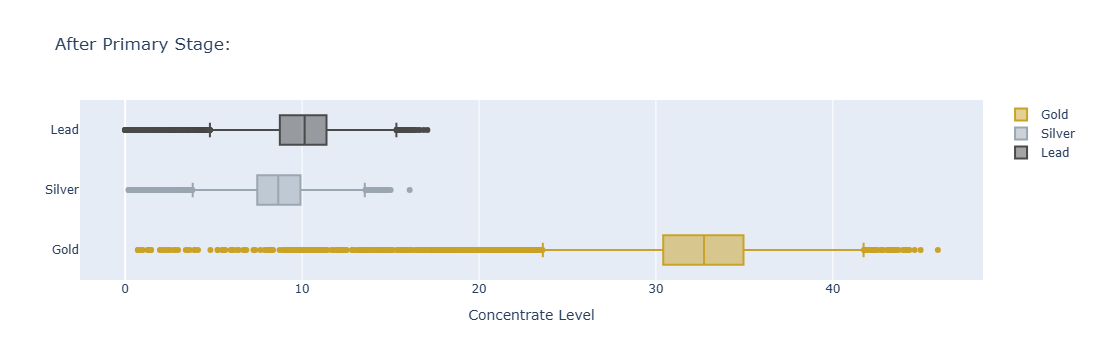

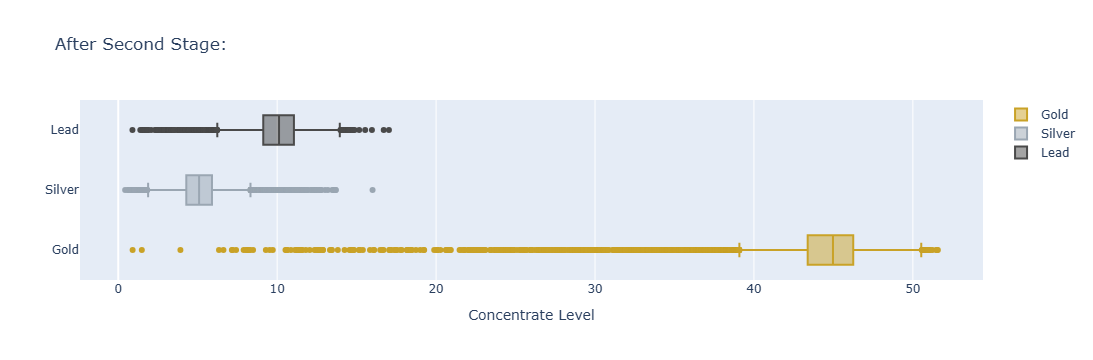

In [69]:
concen_all = {'Gold': ['primary_cleaner.output.concentrate_au', 'final.output.concentrate_au'],
            'Silver': ['primary_cleaner.output.concentrate_ag', 'final.output.concentrate_ag'],
            'Lead': ['primary_cleaner.output.concentrate_pb', 'final.output.concentrate_pb']}

colors = {
    'Gold': '#C9A227',
    'Silver': '#9AA6B2',
    'Lead': '#4A4A4A'
}

fig_1 = go.Figure()
fig_2 = go.Figure()

for key, val in concen_all.items():
    fig_1.add_trace(go.Box(x=df_full[val[0]],
                           name=key, 
                           marker_color=colors[key]))
    
    fig_2.add_trace(go.Box(x=df_full[val[1]], 
                           name=key,
                          marker_color=colors[key]))

fig_1.update_layout(title='After Primary Stage:',
    xaxis_title='Concentrate Level')

fig_2.update_layout(title='After Second Stage:',
    xaxis_title='Concentrate Level')

fig_1.show()
fig_2.show()

<span style="font-size:16px;">

An upward trend is observed in gold concentration, whereas silver shows a decline, and lead remains approximately unchanged.
</span>

### Distribution of Feed Particle Size

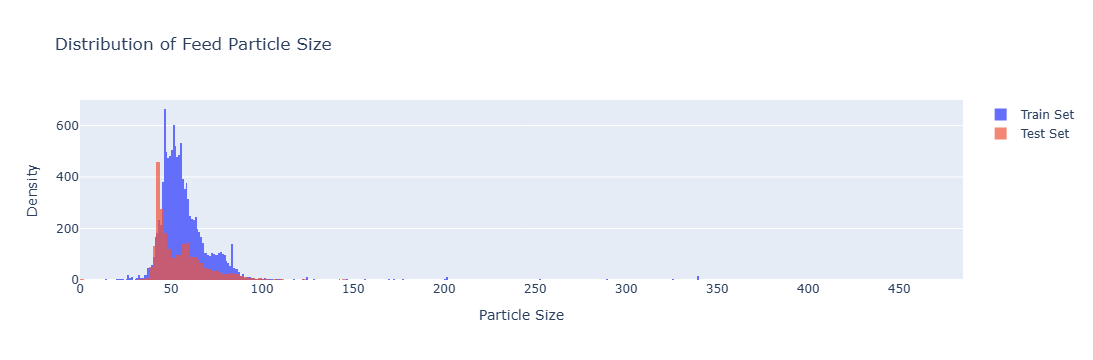

In [68]:
fig = go.Figure()

fig.add_trace(go.Histogram(x=df_train['rougher.input.feed_size'], 
                           histnorm='density', 
                           name='Train Set'))

fig.add_trace(go.Histogram(x=df_test['rougher.input.feed_size'], 
                           histnorm='density', 
                           name='Test Set', opacity=0.7))

fig.update_layout(barmode='overlay',
                title='Distribution of Feed Particle Size',
                xaxis_title='Particle Size',
                yaxis_title='Density')

fig.show()

<span style="font-size:16px;">

Both distributions are negatively skewed, with the majority of particle feed sizes falling between 40 and 100. However, their densities differ: the test dataset is more concentrated in the 40–50 range, whereas the training dataset demonstrates a broader, more evenly dispersed distribution.

</span>

### Total Concentrations of All Substances

<span style="font-size:16px;">
    
We examine the overall distribution of substance concentrations to identify **potential anomalies** in the dataset.

</span>

In [24]:
rougher_input = ['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb']
rougher_output = ['rougher.output.concentrate_au', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb']
primary_clean_output = ['primary_cleaner.output.concentrate_au', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb']
final_output = ['final.output.concentrate_au', 'final.output.concentrate_ag', 'final.output.concentrate_pb']

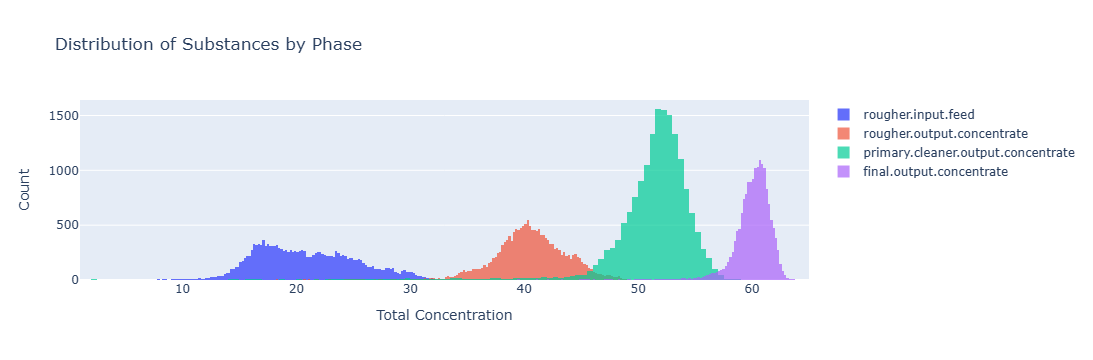

In [67]:
fig = go.Figure()

fig.add_trace(go.Histogram(x=df_full[rougher_input].sum(axis=1), 
                           name='rougher.input.feed'))

fig.add_trace(go.Histogram(x=df_full[rougher_output].sum(axis=1), 
                           name='rougher.output.concentrate', opacity=0.7))

fig.add_trace(go.Histogram(x=df_full[primary_clean_output].sum(axis=1), 
                           name='primary.cleaner.output.concentrate', opacity=0.7))

fig.add_trace(go.Histogram(x=df_full[final_output].sum(axis=1), 
                           name='final.output.concentrate', opacity=0.7))

fig.update_layout(barmode='overlay',
                title='Distribution of Substances by Phase',
                xaxis_title='Total Concentration',
                yaxis_title='Count')

fig.show()

<span style="font-size:16px;">

Around **600** observations across all four phases exhibit combined metal concentrations close to zero. These data points will be investigated to assess whether they represent **anomalies** and should be excluded from the dataset.
</span>

In [26]:
cols = ['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb', 'rougher.input.feed_sol',
        'rougher.output.concentrate_au', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol',
        'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol',
        'final.output.concentrate_au', 'final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol']

display(df_full[df_full[rougher_input].sum(axis=1) < 1][cols])
display(df_full[df_full[rougher_output].sum(axis=1) < 1][cols])
display(df_full[df_full[primary_clean_output].sum(axis=1) < 1][cols])
display(df_full[df_full[final_output].sum(axis=1) < 1][cols])

,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.output.concentrate_au,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,final.output.concentrate_au,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol
18891,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,36.306431,7.925334,9.014648,10.577148,45.270618,5.413548,9.389648,8.731319
18892,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,36.306431,7.925334,9.014648,10.577148,45.270618,5.413548,9.389648,8.731319
18893,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,36.306431,7.925334,9.014648,10.577148,45.270618,5.413548,9.389648,8.731319
18894,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,36.306431,7.925334,9.014648,10.577148,45.270618,5.413548,9.389648,8.731319
18895,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,28.410152,6.203355,7.055690,8.278268,35.424183,4.238007,7.349108,6.833999


,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.output.concentrate_au,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,final.output.concentrate_au,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol
45,7.114065,7.521974,2.811569,41.154430,0.00,0.00,0.00,0.00,37.633572,8.513177,9.724797,19.120964,46.614456,4.566664,10.406178,4.588698
46,7.651522,7.313187,2.973841,41.983063,0.00,0.00,0.00,0.00,37.718947,8.466262,9.780929,19.220963,46.250638,4.577832,10.691605,5.274175
47,5.587750,7.934791,1.763437,41.983063,0.00,0.00,0.00,0.00,38.624404,8.092185,9.719728,19.077471,46.663335,4.591462,10.628846,5.688961
51,7.039270,7.835670,2.770323,38.010139,0.00,0.00,0.00,0.00,34.822988,9.877097,8.932357,19.111308,45.267942,5.759800,9.537415,3.997737
52,7.321526,8.027547,3.073579,39.417952,0.00,0.00,0.00,0.00,32.413685,10.806964,9.382084,19.502217,43.237493,5.807253,10.439505,6.512951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18891,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,36.306431,7.925334,9.014648,10.577148,45.270618,5.413548,9.389648,8.731319
18892,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,36.306431,7.925334,9.014648,10.577148,45.270618,5.413548,9.389648,8.731319
18893,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,36.306431,7.925334,9.014648,10.577148,45.270618,5.413548,9.389648,8.731319
18894,0.010000,0.010000,0.010000,0.010000,0.01,0.01,0.01,0.01,36.306431,7.925334,9.014648,10.577148,45.270618,5.413548,9.389648,8.731319


,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.output.concentrate_au,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,final.output.concentrate_au,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol
19,6.801254,6.046063,2.777324,40.381002,18.511902,10.788951,7.537074,26.092838,0.00,0.00,0.00,0.00,42.509402,5.658943,10.436002,5.942418
22,6.610732,5.599324,2.525838,41.302359,18.089134,10.958096,7.267608,25.911055,0.00,0.00,0.00,0.00,41.406172,6.118749,10.483007,6.546983
30,6.524249,5.689557,2.508414,43.042457,17.583602,11.574823,7.384216,25.740506,0.00,0.00,0.00,0.00,44.059908,5.322681,9.577672,4.805490
73,7.120089,6.994296,2.875142,39.637217,18.414367,10.350497,7.456147,24.962090,0.00,0.00,0.00,0.00,45.135616,4.677499,11.304745,4.655438
76,7.103887,7.844640,2.653501,38.767396,18.614079,10.585663,7.076596,24.024872,0.00,0.00,0.00,0.00,43.264258,4.821388,10.235502,1.581066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22516,10.611729,12.018571,5.802394,36.939986,19.286963,15.310860,8.999071,30.634365,0.01,0.01,0.01,0.01,46.335757,4.442023,9.238301,8.544080
22517,10.538937,11.879119,5.916240,36.748329,19.694488,15.234636,9.126429,31.524008,0.01,0.01,0.01,0.01,44.961086,4.916341,9.644849,8.945859
22518,10.379927,11.407120,6.154015,36.986787,19.411162,14.731266,9.299917,31.440318,0.01,0.01,0.01,0.01,44.519141,5.134035,9.683889,9.203260
22519,7.549261,8.270800,4.492912,25.538641,11.142676,8.349079,5.466212,18.159502,0.01,0.01,0.01,0.01,35.313266,4.503756,8.387537,7.408152


,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.output.concentrate_au,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,final.output.concentrate_au,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol
707,5.598971,7.407737,1.934178,31.762853,15.935190,11.803589,7.143475,21.692525,26.238846,8.986696,6.530607,11.969464,0.00,0.00,0.00,0.00
1354,7.786147,8.098125,2.588661,34.896012,18.682162,10.640168,7.565854,24.793448,34.564456,8.701237,7.234158,10.754321,0.00,0.00,0.00,0.00
1355,7.499248,7.832467,2.435125,34.196525,18.231121,10.415491,7.367937,24.200400,34.399450,8.697952,7.119325,10.194141,0.00,0.00,0.00,0.00
1356,7.032278,7.600277,2.265148,31.994985,18.190655,10.197899,7.364725,22.839147,34.303756,8.921656,6.637383,10.291689,0.00,0.00,0.00,0.00
1357,7.021635,7.436860,2.265435,32.541806,18.194323,9.968103,7.282737,22.918014,33.956378,9.239378,6.249012,10.464946,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16861,3.985905,7.342727,1.116701,35.105592,22.586063,16.139433,6.653230,35.403157,6.357625,0.865060,5.587420,4.361046,0.00,0.00,0.00,0.00
17061,7.275802,8.055075,3.913440,29.234975,20.792589,15.965736,11.492747,33.186725,8.409608,2.342683,11.363321,13.633887,0.00,0.00,0.00,0.00
17084,11.604771,12.464094,5.393215,40.733771,19.442973,14.424928,8.120457,32.367988,34.015777,8.415798,10.210094,11.008945,0.00,0.00,0.00,0.00
17085,11.763586,12.726401,5.630816,39.556916,17.784973,14.028955,8.029784,29.570775,27.937329,11.517548,11.462232,15.168948,0.00,0.00,0.00,0.00


<span style="font-size:16px;">

Identified observations take values of **0.0 or 0.01** for total concentration, while their remaining features appear consistent with typical data. This inconsistency indicates **potential anomalies**. Therefore, these records will be excluded from both `training` and `test` datasets **to avoid biasing the results**.

</span>

In [27]:
dates_to_drop = df_full.loc[
    (df_full[rougher_input].sum(axis=1) < 1) |
    (df_full[rougher_output].sum(axis=1) < 1) |
    (df_full[primary_clean_output].sum(axis=1) < 1) |
    (df_full[final_output].sum(axis=1) < 1),
    'date'
].unique()

# Drop rows in all DataFrames by date
df_full = df_full[~df_full['date'].isin(dates_to_drop)]
df_train = df_train[~df_train['date'].isin(dates_to_drop)]
df_test = df_test[~df_test['date'].isin(dates_to_drop)]

print(df_full.shape)
print(df_train.shape)
print(df_test.shape)

(16930, 87)
(11866, 55)
(5064, 55)


# Model Preparation

### Evaluation Metric
<span style="font-size:16px;">	

Before we build and train the models, we'll need a function to calculate the evaluation metric, **`sMAPE`**.   
**`sMAPE`** is calculated according to the following formula:

$\text{sMAPE} = {1 \over n} \displaystyle\sum_{i=1}^{n} {{|y_i - \hat{y_i}|} \over {(|y_i| + |\hat{y_i}|)/2}} \times 100\%$
- $y_i$: target value for observation $i$
- $\hat{y_i}$: predicted target value for observation $i$
- $n$: number of observations in the sample

We'll define the function, <code>calculate_smape()</code>, to calculate the sMAPE of the predicted values using vector operations:

**Parameters**
- ***actual***: List or Array containing the actual target values.
- ***predict***: List or Array containing the predicted target values.

**Returns**: **`sMAPE`** for the predicted target values.
</span>

In [22]:
def calculate_smape(actual, predict):
    
    # Ensure inputs are numpy arrays for vectorization
    actual, predict = np.array(actual), np.array(predict)
    
    # Added a small epsilon to avoid division by zero
    denominator = (np.abs(actual) + np.abs(predict)) / 2
    
    return 100 * np.mean(np.abs(actual - predict) / (denominator + 1e-9))

<span style="font-size:16px;">	

To facilitate the calculation of the final metric, we'll define the function `calculate_final_smape` that is compatible with the **`scoring`** parameter from **`sklearn.model_selection.cross_val_score`**, as follows:

**Parameters**
- **`estimator`**: Trained model to generate predictions from a given array-like of shape (n_samples, n_features).
- **`features`**: Array-like of shape (n_samples, n_features) containing the validation/test features.
- **`target`**: Array-like of shape (n_samples) containing the true values of the target variable(s).

**Returns**: **`Final sMAPE`** for the predicted targets according to the equation below.
- $\text{Final sMAPE} = 25\% \times \text{sMAPE(rougher)} + 75\% \times \text{sMAPE(final)}$

</span>

In [30]:
def calculate_final_smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    # fix division by zero
    denominator = np.where(denominator == 0, 1e-8, denominator)
    
    smape = np.abs(y_true - y_pred) / denominator
    
    return np.mean(smape) * 100

In [31]:
# If low SMAPE is good, greater_is_better should be False

smape_scorer = make_scorer(calculate_final_smape, greater_is_better=False)

### Feature and Target Selection
<span style="font-size:16px;">	

As noted above, we can only use features available in the test set when training our models. We already have a variable from a previous section, training_columns, that contain the features not available in the test set. Additionally, we'll need to exclude **`date`** column.

</span>

In [32]:
X_train = df_train.drop(['date', 'rougher.output.recovery', 'final.output.recovery'], axis=1)
y_train = df_train[['rougher.output.recovery', 'final.output.recovery']]

print(X_train.shape)
print(y_train.shape)

(11866, 52)
(11866, 2)


In [33]:
X_test = df_test.drop(['date', 'rougher.output.recovery', 'final.output.recovery'], axis=1)
y_test = df_test[['rougher.output.recovery', 'final.output.recovery']]

print(X_test.shape)
print(y_test.shape)

(5064, 52)
(5064, 2)


In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Selection

<span style="font-size:16px;">	

For this project, we selected four widely-used **regression algorithms** to predict gold recovery:

**`Decision Tree Regressor`** <br>
**`Random Forest Regressor`** <br>
**`Linear Regression`** <br>
**`XGBoost Regressor`** <br>

**1. Hyperparameter Tuning:**  
- Apply **`GridSearchCV`** to explore optimal hyperparameters for each model.
- Store results in a DataFrame for clear comparison.
- Perform additional fine-tuning using **`RandomizedSearchCV`** where necessary to further improve model performance.

**2. Model Evaluation:**  
- Compare models using **`Final SMAPE`** as an evaluation metric.
- Identify the model with the lowest **`Final SMAPE`** score, as lower values indicate better predictive performance.

**3.Final Testing**:
- Select the best-performing model based on **`Final SMAPE`**.
- Evaluate this model on the unseen **test set** to measure its real-world performance.

This structured approach ensures that we identify **the most accurate** and reliable model for **predicting gold recovery** while efficiently optimizing model performance. 

</span>

## Dummy Regressor (Baseline)

In [35]:
Dummy = DummyRegressor(strategy='mean')

scores_Dummy = cross_val_score(
    Dummy, 
    X_train, 
    y_train, 
    cv=3, 
    scoring=smape_scorer
)

Dummy.fit(X_train, y_train)

print(f"""
- Dummy Regression Result -

Best Score: {-scores_Dummy.mean():.2f}
""")


- Dummy Regression Result -

Best Score: 9.20



## Linear Regression

In [36]:
LR = LinearRegression()

scores_LR = cross_val_score(
    LR, 
    X_train, 
    y_train, 
    cv=3, 
    scoring=smape_scorer
)

LR.fit(X_train, y_train)

print(f"""
- Linear Regression Result -

Best Score: {-scores_LR.mean():.2f}
""")


- Linear Regression Result -

Best Score: 10.09



## Decision Tree

In [49]:
param_dt = {
    'max_depth': [3, 5, 10, None],        
    'min_samples_split': [2, 10, 20],     
    'min_samples_leaf': [1, 5, 10],       
    'max_features': [None, 'sqrt', 'log2']
}

In [50]:
model = DecisionTreeRegressor(random_state=34)

grid_dt = GridSearchCV(
    model,
    param_dt,
    scoring=smape_scorer,
    cv=3,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

model_DT_best = grid_dt.best_estimator_
score_DT_best = grid_dt.best_score_

print(f"""
- Decision Tree Search Result -

Best Score:     {score_DT_best:.2f}
Best Params:    {grid_dt.best_params_}
""")


- Decision Tree Search Result -

Best Score:     -8.42
Best Params:    {'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}



In [39]:
param_rf = {
    'n_estimators': [100, 200],             
    'max_depth': [None, 10, 20],           
    'min_samples_split': [2, 5],      
    'min_samples_leaf': [1, 2]    
}

In [40]:
model = RandomForestRegressor(random_state=34)

random_rf = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_rf, 
    n_iter=20,                     
    scoring=smape_scorer,
    cv=3,
    n_jobs=-1,
    random_state=34
)

random_rf.fit(X_train, y_train)

model_RF_best = random_rf.best_estimator_
score_RF_best = random_rf.best_score_

print(f"""
- Random Forest Randomized Search Result -

Best Score:     {random_rf.best_score_:.2f}
Best Params:    {random_rf.best_params_}
""")


- Random Forest Randomized Search Result -

Best Score:     -9.19
Best Params:    {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}



## XGBoost

In [41]:
param_xgb = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [44]:
XGB = XGBRegressor(
    random_state=34,
    n_jobs=-1
)

random_search_xgb = RandomizedSearchCV(
    estimator=XGB,
    param_distributions=param_xgb,
    n_iter=30,           
    cv=3,
    scoring=smape_scorer, 
    verbose=0, 
    random_state=34,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

model_XGB_best = random_search_xgb.best_estimator_
score_XGB_best = random_search_xgb.best_score_

print(f"""
- XGBoost Randomized Search Result -

Best Score:     {random_search_xgb.best_score_:.2f}
Best Params:    {random_search_xgb.best_params_}
""")


- XGBoost Randomized Search Result -

Best Score:     -8.14
Best Params:    {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}



In [63]:
results = pd.DataFrame(
    {
    'model': [ 
              'DummyRegressor (Baseline)', 'Linear Regression', 'Decision Tree', 'Random Forest', 
              'XGBoost'],
    
    'final_smape_score': [
              -scores_Dummy.mean(), -scores_LR.mean(), -score_DT_best,               
              -score_RF_best, -random_search_xgb.best_score_],           
    
    }
                            )

In [64]:
print(results)

                       model  final_smape_score
0  DummyRegressor (Baseline)           9.204389
1          Linear Regression          10.093308
2              Decision Tree           8.422736
3              Random Forest           9.193613
4                    XGBoost           8.142136


In [65]:
sorted_smape = results.sort_values(by='final_smape_score')

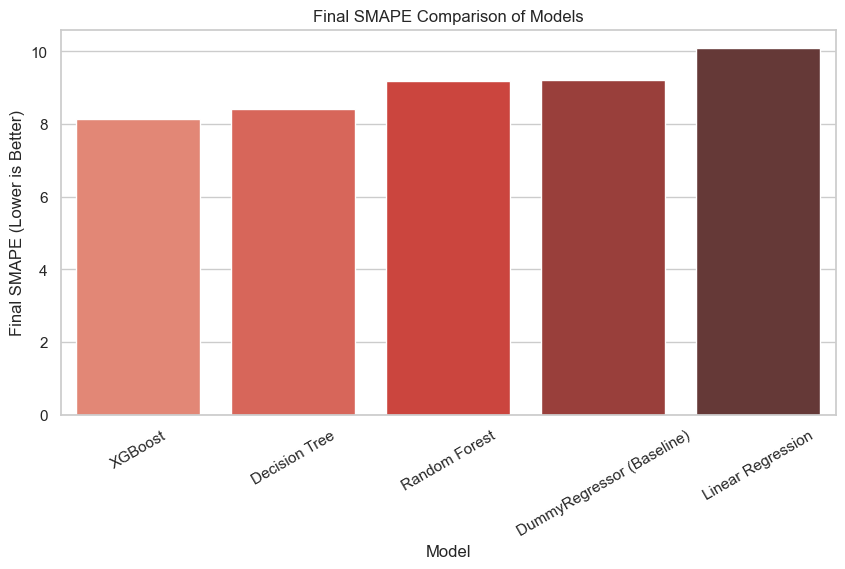

In [66]:
plt.figure(figsize=(10,5))
ax=sns.barplot(x="model", y="final_smape_score", data=sorted_smape, palette="Reds_d")
plt.title("Final SMAPE Comparison of Models")
plt.ylabel("Final SMAPE (Lower is Better)")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.show()

###  Model Performance Insights:

<span style="font-size:16px;">

From the results table:

Lowest **`Final SMAPE`** is achieved by **`XGBoost`** (8.14), indicating it provides the most accurate predictions among all models.  
**`Decision Tree`** (8.42) also performs strongly, slightly behind **`XGBoost`**, showing that even simpler models can capture important patterns in the data.  
**`Random Forest`** (9.19) performs similarly to the **`DummyRegressor`** baseline (9.20), suggesting limited improvement from bagging in this case.  
**`Linear Regression`** (10.09) shows the weakest performance, indicating that the relationship between features and target is likely non-linear and not well captured by a linear model.  

Overall, tree-based models outperform linear approaches, with boosting (**`XGBoost`**) delivering the **best results**.

> **Next**, we will proceed with the best-performing model (**`XGBoost`**) and evaluate it on the unseen test set to confirm its generalization performance.  

</span>

## Test Set

In [54]:
best_model = random_search_xgb.best_estimator_

y_pred = best_model.predict(X_test)

final_smape = calculate_final_smape(y_test, y_pred)


print(f"""
- Best Model (XGBoost) on Test Set -

Final Score:   {final_smape:.2f}
""")


- Best Model (XGBoost) on Test Set -

Final Score:   5.90



# Summary

<span style="font-size:16px;">

In this project, we developed a **regression model** to predict gold recovery from mining process data, focusing on optimizing prediction accuracy using the **`Final SMAPE`** metric.

### Preprocessing:
- **Converted** the `date` column from `object` to `datetime` format for proper time-based handling.  
- **Checked and handled missing values** by creating a custom function `ffill_drop`, applying forward fill grouped by `date` to preserve process consistency.  
- **Aligned datasets**:
  - Added missing **target columns** to the test set from the source dataset.  
  - Ensured the training set contains **only the features available in the test set**, preventing data leakage.  
- **Validated the recovery calculation** to confirm that the target variable is computed correctly.  

### Exploratory Data Analysis (EDA):
- Analyzed **metal concentration changes (Au, Ag, Pb)** across purification stages, confirming expected process behavior.  
- Compared **feed particle size distributions** between training and test sets to check consistency.  
- Examined the **distribution of substance concentrations** to detect anomalies.  
- Identified ~600 observations with **near-zero total metal concentrations**, likely anomalies → these observations were **removed**.  

### Feature Engineering & Scaling:
- Applied **Standard Scaling** to normalize feature distributions.  
- Implemented custom evaluation metrics:
  - `calculate_smape`  
  - `calculate_final_smape`  

### Model Selection & Tuning:
- Evaluated four regression models:
  - `Decision Tree Regressor`  
  - `Random Forest Regressor`  
  - `Linear Regression`  
  - `XGBoost Regressor`  

- Performed hyperparameter tuning using:
  - `GridSearchCV`  
  - `RandomizedSearchCV`  

- Compared models using **Final SMAPE** (lower is better).  

### Best Model:
- **XGBoost** achieved the lowest Final SMAPE among all models.  

- On the **test set**, it achieved:
  - **Final SMAPE: 5.90**

### Insights:
- Tree-based and boosting models outperform linear models, indicating **non-linear relationships** in the data.  
- Improvements over baseline are moderate, suggesting **feature engineering** could further improve results.  
- Removing anomalies and validating domain-specific calculations significantly improved model reliability.  

</span>

### ========================= Conclusion ===============================
<span style="font-size:16px;">

**Final Model Performance** (`Xgboost`):  
**Final_SMAPE**: 5.90 <br>
Compared to the baseline `DummyRegressor` (SMAPE ≈ 9.20), the model improved performance by approximately **36%**, demonstrating a significant gain in predictive accuracy.

</span>